# Analyze manual theta-fit results

Loads a `results.npz` written by `theta_fit.py fit`, computes per-sample
**R² at midpoint** and **R² at end** of the rollout for each observed species,
and lets us inspect samples (with their `u_seq` inputs) that fall below an R² threshold.

Use it to identify input regimes where the scaffold can't fit the data.

In [3]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Edit these two paths --------------------------------------------------------
REPO_ROOT   = Path('/home/overven1/theta-lab')
RESULTS_DIR = REPO_ROOT / 'results/ivtt_theta_fit'                       # contains results.npz
DATASET     = REPO_ROOT / 'datasets/cell-free/real_ivtt_exact_full.npz'  # for u_seq plots
SPECIES     = ['mm', 'pm']                            # which species to score
USE_ROLLOUT = True                                    # else: one-step oracle
# ---------------------------------------------------------------------------

In [4]:
z = np.load(RESULTS_DIR / 'results.npz', allow_pickle=True)
state_names    = [str(s) for s in z['state_names']]
sample_indices = [int(i) for i in z['sample_indices']]
t_obs          = z['t_obs']                  # (K+1,)
y_true         = z['y_true'][:, 1:, :]       # (N, K, P) — drop t0
pred           = z['pred_rollout' if USE_ROLLOUT else 'pred_onestep']
scaffold_name  = str(z['scaffold_name'])

N, K, P = y_true.shape
print(f'scaffold = {scaffold_name}')
print(f'N = {N},  K = {K},  P = {P},  species = {state_names}')
print(f'using {"rollout" if USE_ROLLOUT else "one-step"} predictions')

scaffold = ivtt_analytic
N = 695,  K = 1497,  P = 7,  species = ['R', 'O', 'm', 'mm', 'p', 'pm', '_']
using rollout predictions


## Compute summary R²

For this cell-free reaction the two scalars we care about per sample are:

- **`max_mm`** — value of `mm` at the time of its true peak (we evaluate the predicted trajectory at the same time index)
- **`end_pm`** — value of `pm` at the final observed time

`R²` is reported **across samples** (population R²: 1 − Σ(true−pred)² / Σ(true−mean(true))²). The per-sample residuals are kept for filtering/plotting individual samples.

In [5]:
def population_r2(true, pred):
    """Population R² across samples. true/pred: (N,) scalars per sample."""
    ss_res = np.sum((true - pred) ** 2)
    ss_tot = np.sum((true - true.mean()) ** 2)
    ss_tot = max(ss_tot, 1e-12)
    return 1.0 - ss_res / ss_tot

# Per-sample scalars at the points of interest
j_mm = state_names.index('mm')
j_pm = state_names.index('pm')

# mm at its true peak (per-sample): use the time index of the true max
t_peak_mm        = np.argmax(y_true[:, :, j_mm], axis=1)        # (N,)
mm_peak_true     = y_true[np.arange(N), t_peak_mm, j_mm]
mm_peak_pred     = pred  [np.arange(N), t_peak_mm, j_mm]

# pm at endpoint
pm_end_true      = y_true[:, -1, j_pm]
pm_end_pred      = pred  [:, -1, j_pm]

# Per-sample signed residuals (for filtering / plot titles)
resid = {
    'mm_peak': mm_peak_pred - mm_peak_true,
    'pm_end' : pm_end_pred  - pm_end_true,
}

# Population R² (scalars)
R2_pop = {
    'mm_peak': population_r2(mm_peak_true, mm_peak_pred),
    'pm_end' : population_r2(pm_end_true,  pm_end_pred),
}
print(f"R²  max(mm)  = {R2_pop['mm_peak']:.4f}   (N={N})")
print(f"R²  end(pm)  = {R2_pop['pm_end']:.4f}")

import pandas as pd
df = pd.DataFrame({
    'sample_idx'   : sample_indices,
    't_peak_mm'    : t_peak_mm,
    'mm_peak_true' : mm_peak_true,
    'mm_peak_pred' : mm_peak_pred,
    'mm_peak_err'  : resid['mm_peak'],
    'pm_end_true'  : pm_end_true,
    'pm_end_pred'  : pm_end_pred,
    'pm_end_err'   : resid['pm_end'],
})
df.describe().round(4)

R²  max(mm)  = 0.9945   (N=695)
R²  end(pm)  = -0.1206


,sample_idx,t_peak_mm,mm_peak_true,mm_peak_pred,mm_peak_err,pm_end_true,pm_end_pred,pm_end_err
count,695.0000,695.0000,695.0000,695.0000,695.0000,695.0000,695.0000,695.0000
mean,347.0000,292.0201,59.3482,56.7811,-2.5671,666.4655,149.0863,-517.3792
std,200.7735,345.5537,99.4229,95.0129,6.9440,912.7529,193.3523,815.7913
min,0.0000,0.0000,0.0000,0.0057,-112.3638,0.0000,0.3783,-5870.2158
25%,173.5000,122.0000,16.0000,14.7009,-2.6684,93.2500,36.7740,-639.3838
50%,347.0000,160.0000,27.0000,26.0085,-0.5121,382.5000,98.2545,-246.4285
75%,520.5000,260.5000,49.0000,47.3247,-0.0005,820.2500,189.9127,-32.9746
max,694.0000,1481.0000,683.0000,662.7052,0.1175,6355.0000,1870.6418,57.3927


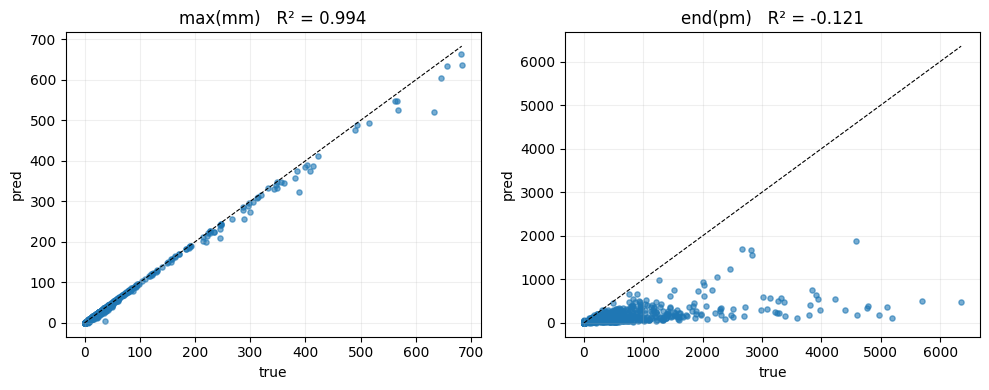

In [6]:
# Parity plots: pred vs true at the two points of interest
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (tag, t, p) in zip(axes, [
    ('max(mm)', mm_peak_true, mm_peak_pred),
    ('end(pm)', pm_end_true,  pm_end_pred),
]):
    ax.scatter(t, p, s=14, alpha=0.6)
    lo, hi = float(min(t.min(), p.min())), float(max(t.max(), p.max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8)
    ax.set_xlabel('true'); ax.set_ylabel('pred')
    ax.set_title(f'{tag}   R² = {R2_pop[tag.replace("max(mm)","mm_peak").replace("end(pm)","pm_end")]:.3f}')
    ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

## Test-set R² (manual theta fit)

Restrict the population R² above to the held-out test indices from
`datasets/cell-free/ivtt_3seed_splits.npz`. The splits store global sample
indices, which match `sample_indices` from the fit results.

In [7]:
SPLITS_PATH = REPO_ROOT / 'datasets/cell-free/ivtt_3seed_splits.npz'
SEEDS       = [0, 1, 2]

splits = np.load(SPLITS_PATH, allow_pickle=True)
fit_idx_to_row = {gi: row for row, gi in enumerate(sample_indices)}

rows = []
for seed in SEEDS:
    test_global = splits[f'test_{seed}']
    rows_in_fit = np.array([fit_idx_to_row[int(g)] for g in test_global if int(g) in fit_idx_to_row], dtype=int)
    n_missing   = int(len(test_global) - len(rows_in_fit))

    if len(rows_in_fit) == 0:
        rows.append({'seed': seed, 'n_test': int(len(test_global)), 'n_evaluated': 0,
                     'n_missing': n_missing, 'R2_max_mm': np.nan, 'R2_end_pm': np.nan})
        continue

    r2_mm = population_r2(mm_peak_true[rows_in_fit], mm_peak_pred[rows_in_fit])
    r2_pm = population_r2(pm_end_true [rows_in_fit], pm_end_pred [rows_in_fit])
    rows.append({
        'seed'        : seed,
        'n_test'      : int(len(test_global)),
        'n_evaluated' : int(len(rows_in_fit)),
        'n_missing'   : n_missing,
        'R2_max_mm'   : r2_mm,
        'R2_end_pm'   : r2_pm,
    })

test_r2 = pd.DataFrame(rows)
mean_row = {
    'seed'        : 'mean',
    'n_test'      : test_r2['n_test'].sum(),
    'n_evaluated' : test_r2['n_evaluated'].sum(),
    'n_missing'   : test_r2['n_missing'].sum(),
    'R2_max_mm'   : test_r2['R2_max_mm'].mean(),
    'R2_end_pm'   : test_r2['R2_end_pm'].mean(),
}
test_r2 = pd.concat([test_r2, pd.DataFrame([mean_row])], ignore_index=True)
test_r2.round(4)

,seed,n_test,n_evaluated,n_missing,R2_max_mm,R2_end_pm
0,0,86,86,0,0.9984,-0.0898
1,1,86,86,0,0.9962,-0.1503
2,2,86,86,0,0.9912,-0.0272
3,mean,258,258,0,0.9953,-0.0891


## Filter samples by per-sample relative error

Population R² is one scalar; for picking *individual* bad samples we rank by
relative error at the target point.

In [8]:
REL_ERR_THRESHOLD = 0.25   # |pred-true| / max(|true|, eps)
TARGET = 'pm_end'          # 'mm_peak' or 'pm_end'

true_col, pred_col = f'{TARGET}_true', f'{TARGET}_pred'
df['rel_err_' + TARGET] = np.abs(df[pred_col] - df[true_col]) / np.maximum(np.abs(df[true_col]), 1e-9)

bad  = df[df['rel_err_' + TARGET] >= REL_ERR_THRESHOLD].sort_values('rel_err_' + TARGET, ascending=False)
good = df[df['rel_err_' + TARGET] <  REL_ERR_THRESHOLD].sort_values('rel_err_' + TARGET)
print(f'{len(bad)} / {len(df)} samples with rel-err >= {REL_ERR_THRESHOLD} on {TARGET}')
bad.head(20)

652 / 695 samples with rel-err >= 0.25 on pm_end


,sample_idx,t_peak_mm,mm_peak_true,mm_peak_pred,mm_peak_err,pm_end_true,pm_end_pred,pm_end_err,rel_err_pm_end
587,587,1174,566.0,548.054504,-17.945496,0.0,44.208981,44.208981,4.420898e+10
687,687,270,227.0,226.932541,-0.067459,0.0,35.178444,35.178444,3.517845e+10
672,672,250,68.0,67.611671,-0.388329,0.0,33.228283,33.228283,3.322828e+10
50,50,402,131.0,130.955353,-0.044647,0.0,28.324425,28.324425,2.832443e+10
68,68,1382,297.0,294.794250,-2.205750,0.0,27.525831,27.525831,2.752583e+10
685,685,165,26.0,25.435148,-0.564852,0.0,27.111277,27.111277,2.711128e+10
415,415,1470,141.0,138.167618,-2.832382,0.0,25.763308,25.763308,2.576331e+10
417,417,93,15.0,14.998823,-0.001177,0.0,25.351231,25.351231,2.535123e+10
224,224,261,31.0,30.228996,-0.771004,0.0,24.368654,24.368654,2.436865e+10
235,235,730,189.0,187.648560,-1.351440,0.0,24.110428,24.110428,2.411043e+10


## Inspect one sample: predictions + inputs

Pick a sample from the `bad` (or `good`) table above and see why it diverges.

In [9]:
d = np.load(DATASET, allow_pickle=True)
u_seq_all = d['u_seq']                              # (N_total, K, U)
u_names   = [str(s) for s in d['control_names']] if 'control_names' in d.files else \
            [f'u{i}' for i in range(u_seq_all.shape[-1])]
print(f'u channels ({len(u_names)}): {u_names}')

u channels (12): ['3PGA', 'AA', 'DNA c', 'FB', 'K-Glut', 'Lysate 2%PEG', 'Maltose', 'Mg-Glut', 'NTPs', 'PEG8000', 'T7RNAP', 'water']


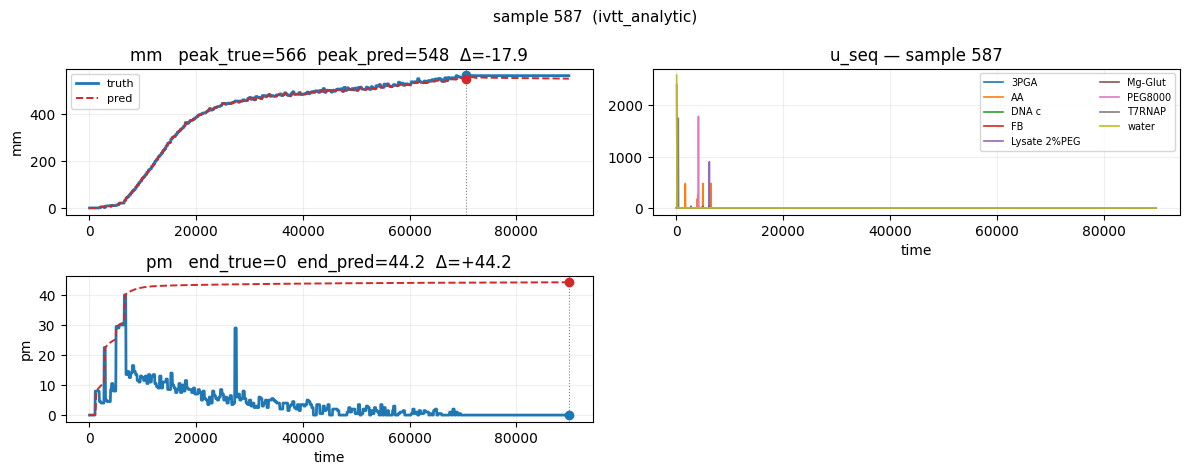

In [10]:
def plot_sample(sample_idx, drop_u_zero=True):
    """Side-by-side: predictions vs truth (per species) + u inputs."""
    ni = sample_indices.index(sample_idx)
    tt = t_obs[1:]

    nrows = max(len(SPECIES), 1)
    fig, axes = plt.subplots(nrows, 2, figsize=(12, 2.4 * nrows), squeeze=False)

    # Left column: predictions per species, annotated with the metric we care about
    for r, sp in enumerate(SPECIES):
        j = state_names.index(sp)
        ax = axes[r][0]
        ax.plot(tt, y_true[ni, :, j], lw=2.0, label='truth', color='tab:blue')
        ax.plot(tt, pred[ni,   :, j], lw=1.4, label='pred',  color='tab:red', ls='--')

        if sp == 'mm':
            k_peak = int(t_peak_mm[ni])
            ax.axvline(tt[k_peak], color='gray', ls=':', lw=0.8)
            ax.scatter([tt[k_peak]], [y_true[ni, k_peak, j]], color='tab:blue', zorder=3)
            ax.scatter([tt[k_peak]], [pred  [ni, k_peak, j]], color='tab:red',  zorder=3)
            err = resid['mm_peak'][ni]
            ax.set_title(f'mm   peak_true={mm_peak_true[ni]:.3g}  peak_pred={mm_peak_pred[ni]:.3g}  Δ={err:+.3g}')
        elif sp == 'pm':
            ax.axvline(tt[-1], color='gray', ls=':', lw=0.8)
            ax.scatter([tt[-1]], [pm_end_true[ni]], color='tab:blue', zorder=3)
            ax.scatter([tt[-1]], [pm_end_pred[ni]], color='tab:red',  zorder=3)
            err = resid['pm_end'][ni]
            ax.set_title(f'pm   end_true={pm_end_true[ni]:.3g}  end_pred={pm_end_pred[ni]:.3g}  Δ={err:+.3g}')
        else:
            ax.set_title(sp)

        ax.set_ylabel(sp); ax.grid(alpha=0.2)
        if r == 0: ax.legend(fontsize=8)
    axes[-1][0].set_xlabel('time')

    # Right column: u inputs (stacked on one axis)
    u = u_seq_all[sample_idx]                         # (K, U)
    ax = axes[0][1]
    for u_i in range(u.shape[1]):
        col = u[:, u_i]
        if drop_u_zero and np.allclose(col, 0):
            continue
        ax.plot(tt, col, lw=1.2, label=u_names[u_i])
    ax.set_title(f'u_seq — sample {sample_idx}')
    ax.set_xlabel('time'); ax.legend(fontsize=7, ncol=2); ax.grid(alpha=0.2)
    for r in range(1, nrows):
        axes[r][1].axis('off')

    fig.suptitle(f'sample {sample_idx}  ({scaffold_name})', fontsize=11)
    plt.tight_layout(); plt.show()

# Worst-fit sample
if len(bad):
    plot_sample(int(bad.iloc[0]['sample_idx']))

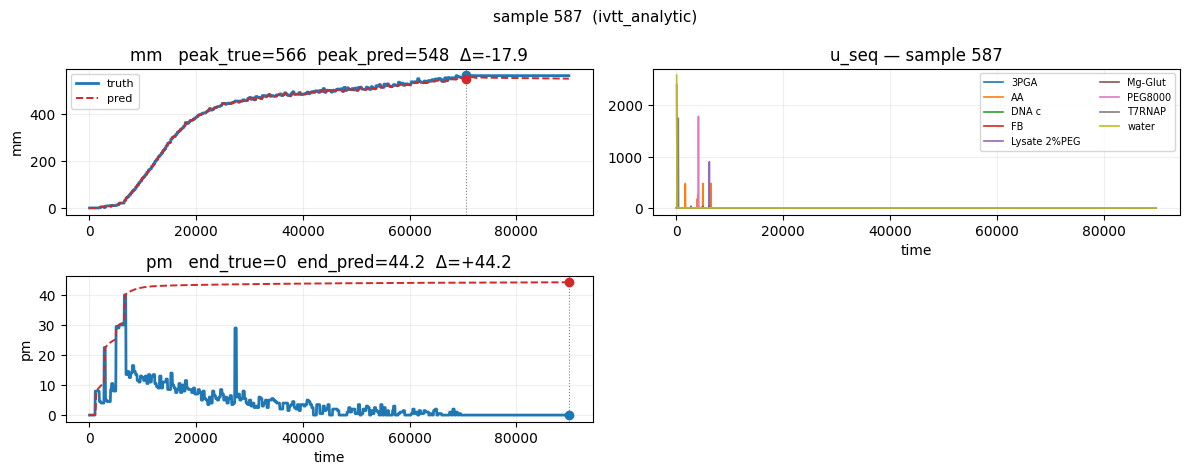

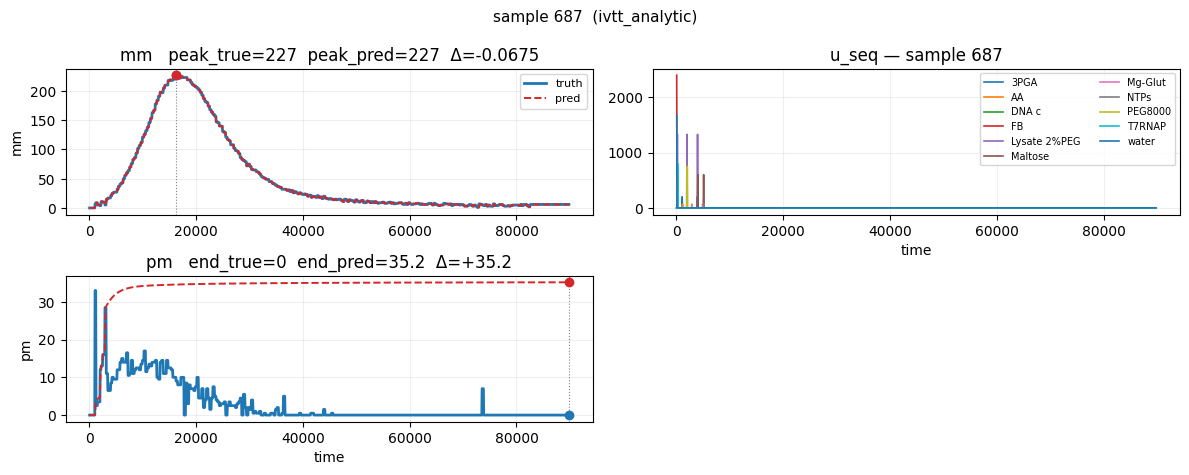

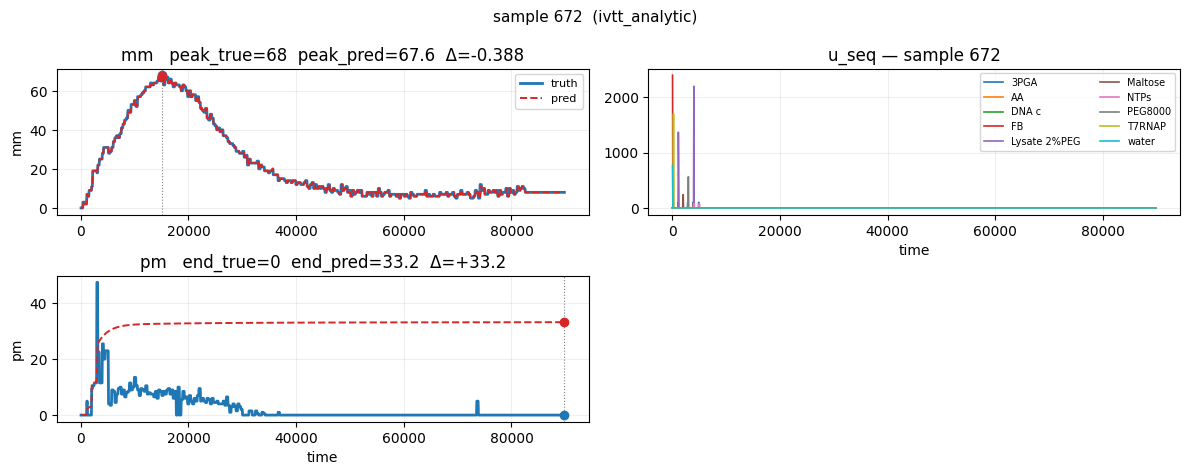

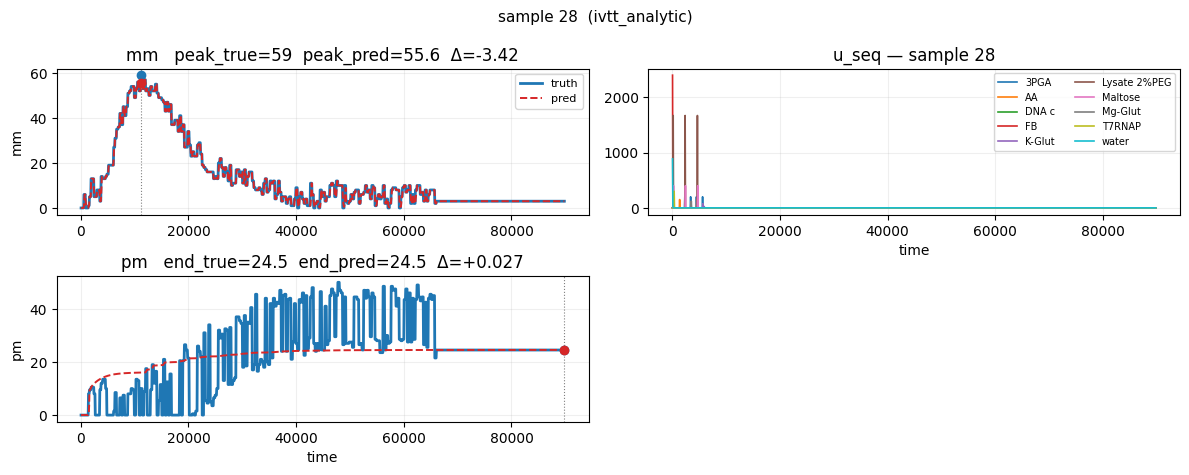

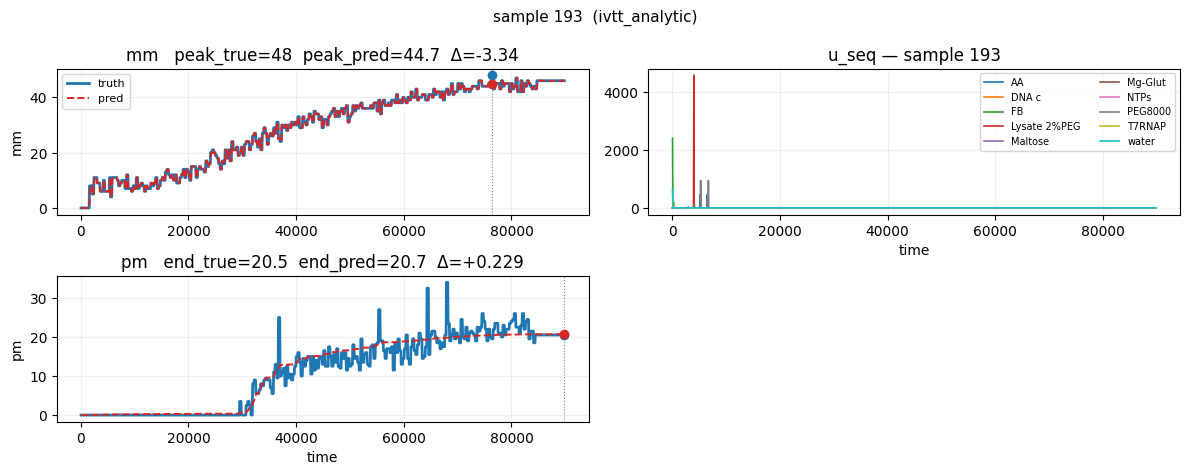

In [11]:
# Compare a few of the worst vs best fits side by side
for si in list(bad['sample_idx'].head(3)):
    plot_sample(int(si))
for si in list(good['sample_idx'].head(2)):
    plot_sample(int(si))

## Look for input-regime patterns in failing samples

Mean / range of each u channel for bad vs good. Big differences = candidate failure regimes.

In [12]:
def u_summary(sample_idx_list):
    arr = u_seq_all[np.array(sample_idx_list, dtype=int)]   # (n, K, U)
    return pd.DataFrame({
        'channel'  : u_names,
        'mean'     : arr.mean(axis=(0, 1)),
        'max'      : arr.max(axis=(0, 1)),
        'fraction_nonzero': (arr != 0).mean(axis=(0, 1)),
    })

print('--- BAD samples ---'); print(u_summary(bad['sample_idx'].tolist()).round(4))
print('--- GOOD samples ---'); print(u_summary(good['sample_idx'].tolist()).round(4))

--- BAD samples ---
         channel    mean        max  fraction_nonzero
0           3PGA  0.1236   700.0000            0.0009
1             AA  0.1880  2700.0000            0.0008
2          DNA c  0.0013    26.7925            0.0087
3             FB  1.6032  2400.0000            0.0007
4         K-Glut  0.2865  1200.0000            0.0009
5   Lysate 2%PEG  2.7209  6000.0000            0.0011
6        Maltose  0.2405  1200.0000            0.0010
7        Mg-Glut  0.1173   360.0000            0.0011
8           NTPs  0.0344  1050.0000            0.0005
9        PEG8000  0.8092  3750.0000            0.0011
10        T7RNAP  0.4162  1800.0000            0.0007
11         water  1.1791  4660.0000            0.0007
--- GOOD samples ---
         channel    mean        max  fraction_nonzero
0           3PGA  0.1281   700.0000            0.0009
1             AA  0.2695   575.0000            0.0010
2          DNA c  0.0013     7.5769            0.0088
3             FB  1.6032  2400.0000      